# City Predictor Machine-learning Project

Below is extensive testing and protoryping to better understand which model architecture is best fit for the task at hand.
That is, we determine which model is best at determining if a given data point describes **New York City**, **Dubai**,
**Rio de Janeiro**, or **Paris**. We will be exploring some tranformations of the provided dataset, and test out the performance of various model families.

In [1]:
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Now, we load the data into pandas:

In [2]:
data = pd.read_csv("data/cleaned_dataset.csv")
del data['id'] #remove id column since it is of no use
data

,Popularity,Virality,Architecure,Parties,Company,Relatable,Temperature,Languages,Styles,Quote,Label
0,4,1.0,2.0,1,Co-worker,"Skyscrapers=>6,Sport=>4,Art and Music=>2,Carni...",25,7.0,100,Slavery,Dubai
1,4,3.0,5.0,2,Co-worker,"Skyscrapers=>6,Sport=>1,Art and Music=>2,Carni...",20,3.0,4,"Wherever there is great property, there is gre...",Dubai
2,5,4.0,5.0,1,"Partner,Friends","Skyscrapers=>6,Sport=>2,Art and Music=>3,Carni...",32,5.0,4,Futuristic land,Dubai
3,5,4.0,4.0,1,"Partner,Friends","Skyscrapers=>6,Sport=>5,Art and Music=>1,Carni...",23,10.0,3,The city where anything is possible,Dubai
4,4,3.0,3.0,3,"Partner,Friends,Siblings","Skyscrapers=>6,Sport=>4,Art and Music=>1,Carni...",20,10.0,5,"If you can think of a high building, it probab...",Dubai
...,...,...,...,...,...,...,...,...,...,...,...
1457,4,2.0,5.0,3,"Partner,Friends,Siblings","Skyscrapers=>2,Sport=>1,Art and Music=>4,Carni...",5,2.0,2,"""The average piece of junk is probably more me...",Paris
1458,5,3.0,4.0,2,"Partner,Co-worker","Skyscrapers=>1,Sport=>3,Art and Music=>6,Carni...",7,2.0,4,Oui oui baguette,Paris
1459,2,1.0,3.0,4,Friends,"Skyscrapers=>2,Sport=>3,Art and Music=>6,Carni...",9,87.0,67,E OhÂ,Paris
1460,5,4.0,5.0,3,"Partner,Friends","Skyscrapers=>5,Sport=>6,Art and Music=>2,Carni...",15,1.0,15,croissants and cigarettesÂ,Paris


Now, since the "relatable" column has too many unique values, and won't provide much insight for any standard models, we split the relatability scores
into seperate columns:

In [3]:
upd_data = pd.read_csv("data/cleaned_dataset_split.csv")
del upd_data['id'] #remove id column since it is of no use
upd_data

,Popularity,Virality,Architecure,Parties,Company,rel_Art and Music,rel_Carnival,rel_Cuisine,rel_Economic,rel_Skyscrapers,rel_Sport,Temperature,Languages,Styles,Quote,Label
0,4,1.0,2.0,1,Co-worker,2,1,3.0,5,6,4,25,7.0,100,Slavery,Dubai
1,4,3.0,5.0,2,Co-worker,2,3,4.0,5,6,1,20,3.0,4,"Wherever there is great property, there is gre...",Dubai
2,5,4.0,5.0,1,"Partner,Friends",3,3,4.0,5,6,2,32,5.0,4,Futuristic land,Dubai
3,5,4.0,4.0,1,"Partner,Friends",1,2,4.0,3,6,5,23,10.0,3,The city where anything is possible,Dubai
4,4,3.0,3.0,3,"Partner,Friends,Siblings",1,2,3.0,5,6,4,20,10.0,5,"If you can think of a high building, it probab...",Dubai
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1457,4,2.0,5.0,3,"Partner,Friends,Siblings",4,6,5.0,3,2,1,5,2.0,2,"""The average piece of junk is probably more me...",Paris
1458,5,3.0,4.0,2,"Partner,Co-worker",6,2,5.0,4,1,3,7,2.0,4,Oui oui baguette,Paris
1459,2,1.0,3.0,4,Friends,6,2,2.0,5,2,3,9,87.0,67,E OhÂ,Paris
1460,5,4.0,5.0,3,"Partner,Friends",2,3,1.0,4,5,6,15,1.0,15,croissants and cigarettesÂ,Paris


Much better! On that note, we also wish to split the "company" column into one-hot columns. That is, we will expand the column into
four distinct _binary_ columns: bring_friends, bring_coworker, bring_partner and bring_siblings. Additionally, to simplify the training
process for now, we will exclude the "Quote" column and add it later on.

In [4]:
complete_data = pd.read_csv("data/cleaned_dataset_complete.csv")
del complete_data['id']
del complete_data['Quote']
feature_cols = [c for c in complete_data.columns if c != 'Label']
complete_data[feature_cols] = complete_data[feature_cols].apply(pd.to_numeric, errors='coerce').astype('float64')
complete_data

,Popularity,Virality,Architecure,Parties,bring_Co-worker,bring_Friends,bring_Partner,bring_Siblings,rel_Art and Music,rel_Carnival,rel_Cuisine,rel_Economic,rel_Skyscrapers,rel_Sport,Temperature,Languages,Styles,Label
0,4.0,1.0,2.0,1.0,1.0,0.0,0.0,0.0,2.0,1.0,3.0,5.0,6.0,4.0,25.0,7.0,100.0,Dubai
1,4.0,3.0,5.0,2.0,1.0,0.0,0.0,0.0,2.0,3.0,4.0,5.0,6.0,1.0,20.0,3.0,4.0,Dubai
2,5.0,4.0,5.0,1.0,0.0,1.0,1.0,0.0,3.0,3.0,4.0,5.0,6.0,2.0,32.0,5.0,4.0,Dubai
3,5.0,4.0,4.0,1.0,0.0,1.0,1.0,0.0,1.0,2.0,4.0,3.0,6.0,5.0,23.0,10.0,3.0,Dubai
4,4.0,3.0,3.0,3.0,0.0,1.0,1.0,1.0,1.0,2.0,3.0,5.0,6.0,4.0,20.0,10.0,5.0,Dubai
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1457,4.0,2.0,5.0,3.0,0.0,1.0,1.0,1.0,4.0,6.0,5.0,3.0,2.0,1.0,5.0,2.0,2.0,Paris
1458,5.0,3.0,4.0,2.0,1.0,0.0,1.0,0.0,6.0,2.0,5.0,4.0,1.0,3.0,7.0,2.0,4.0,Paris
1459,2.0,1.0,3.0,4.0,0.0,1.0,0.0,0.0,6.0,2.0,2.0,5.0,2.0,3.0,9.0,87.0,67.0,Paris
1460,5.0,4.0,5.0,3.0,0.0,1.0,1.0,0.0,2.0,3.0,1.0,4.0,5.0,6.0,15.0,1.0,15.0,Paris


At a glance, it seems that the data here is linearly seperable. Let's confirm this by plotting the data out more extensively.

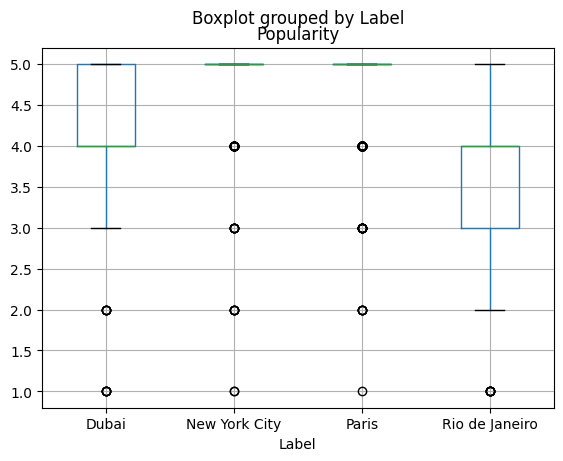

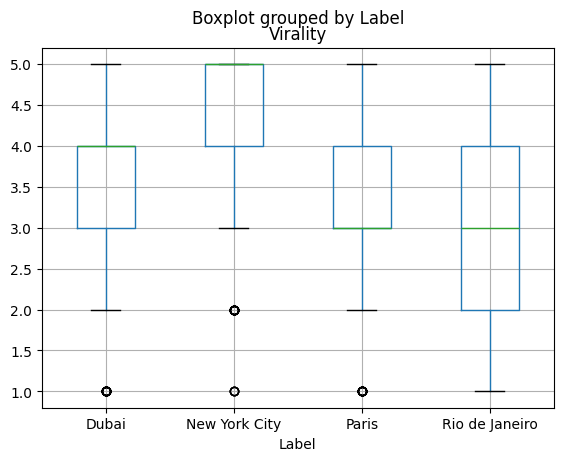

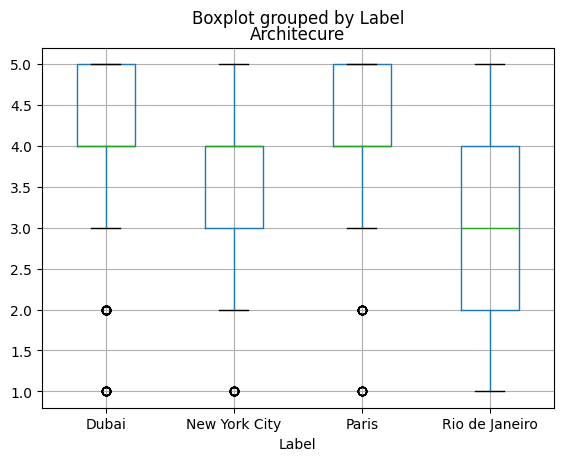

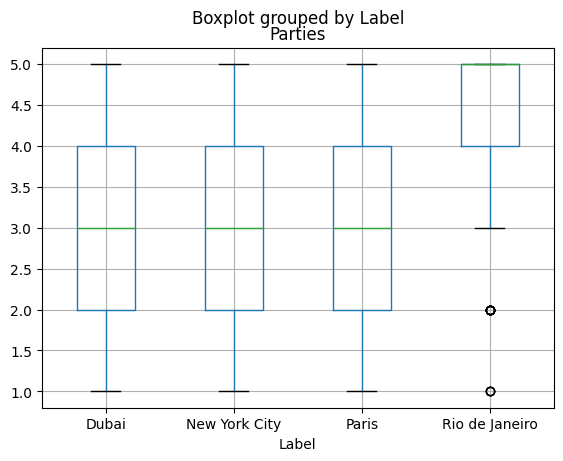

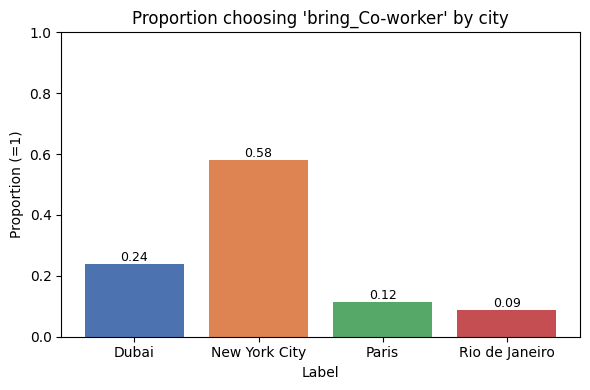

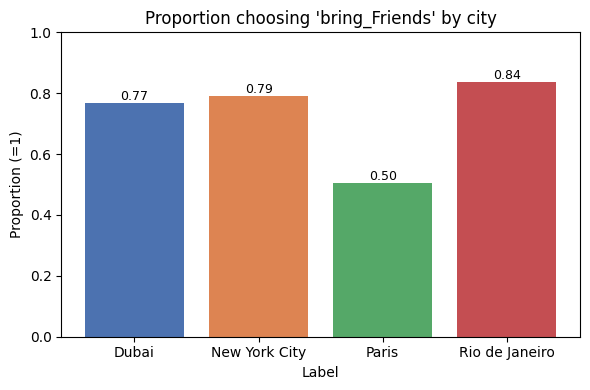

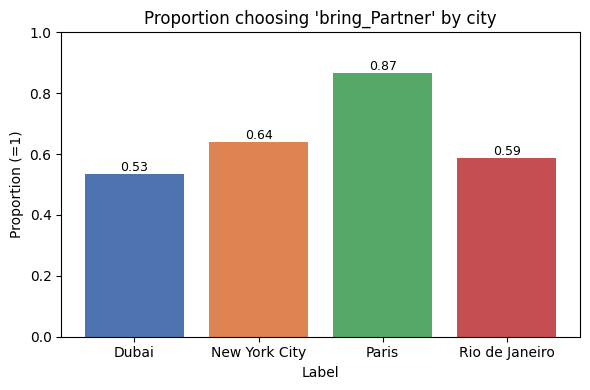

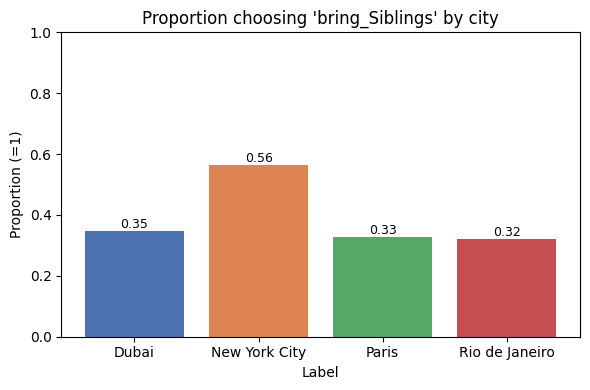

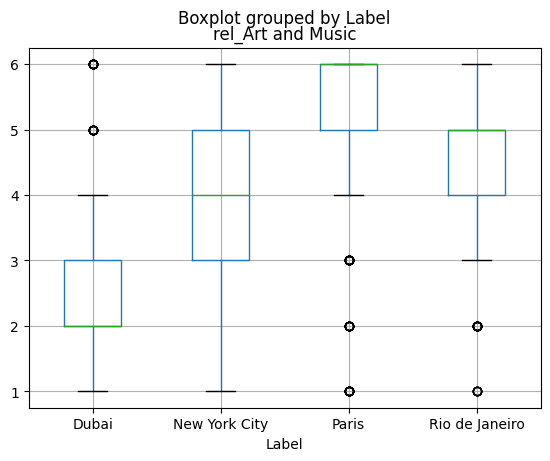

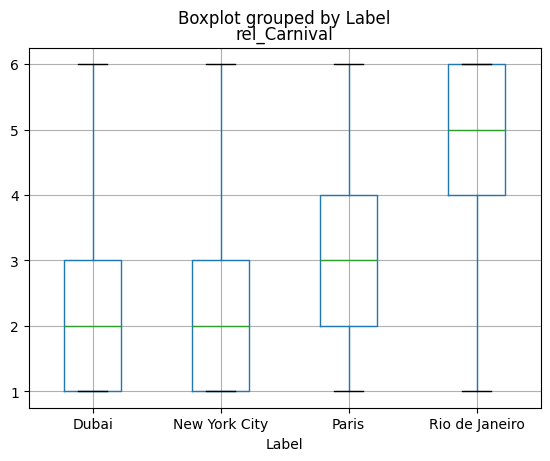

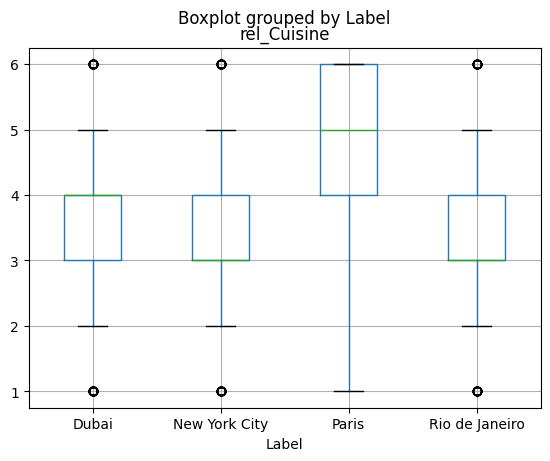

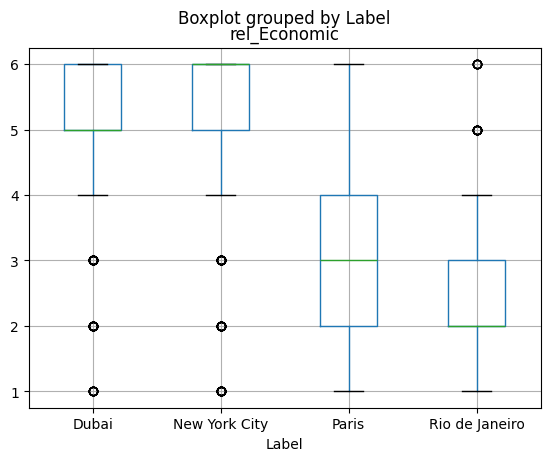

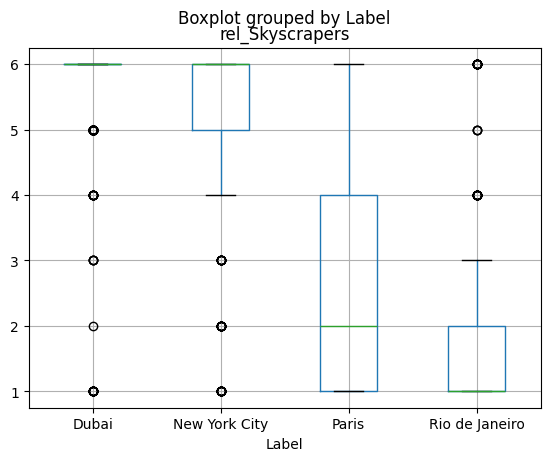

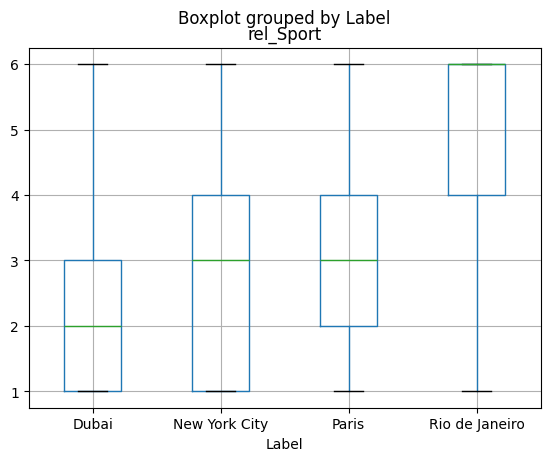

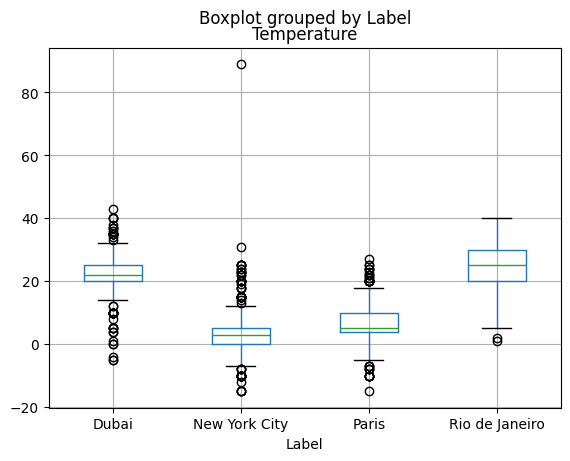

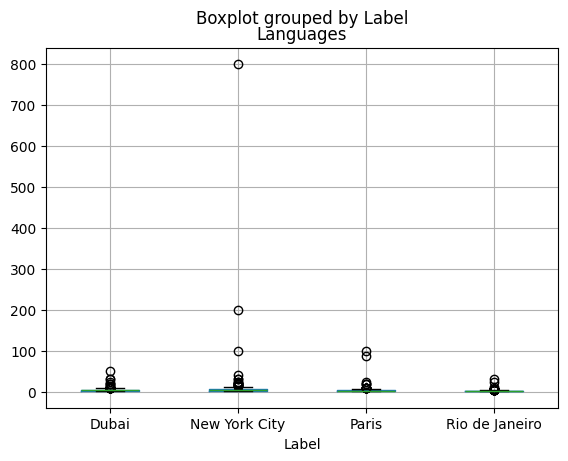

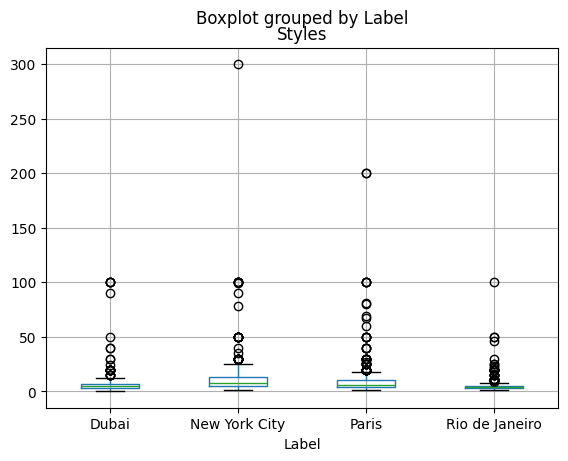

In [5]:
for fet in complete_data:
    if fet == 'Label':
        continue

    # Binary (0/1) features make for useless boxplots, so we instead show
    # the proportion of each city's respondents that selected the option.
    is_binary = set(complete_data[fet].dropna().unique()) <= {0, 1}
    cities = ['Dubai', 'New York City', 'Paris', 'Rio de Janeiro']

    if is_binary:
        props = complete_data.groupby('Label')[fet].mean().reindex(cities)

        fig, ax = plt.subplots(figsize=(6, 4))
        bars = ax.bar(cities, props.values, color=sns.color_palette('deep', len(cities)))
        ax.set_title(f"Proportion choosing '{fet}' by city")
        ax.set_ylabel("Proportion (=1)")
        ax.set_ylim(0, 1)
        ax.set_xlabel('Label')
        for bar, val in zip(bars, props.values):
            ax.annotate(f"{val:.2f}", (bar.get_x() + bar.get_width() / 2, val),
                        ha='center', va='bottom', fontsize=9)
        plt.tight_layout()
    else:
        complete_data.boxplot(column=fet, by='Label')

plt.show()

Indeed, according to the plots, it appears that the data is
quite linearly seperable based on features such as temperature,
relatibility to skyskrapers, and relatability to economic activity.
As a result, this hints that a decision tree can potentially
be an excellent model to use, as linearly seperable data
is exactly the notion that the model is built on. Hence, we must
now first split the data into training, validation, and test sets using
 a 70/30 split:

In [6]:
from sklearn.model_selection import train_test_split

data_fets = np.stack([complete_data[fet] for fet in feature_cols
                      if fet != 'Label'], axis=1)
X = data_fets
t = np.array(data['Label'])

X_tv, X_test, t_tv, t_test = train_test_split(X, t, test_size=219/1461, random_state=1)

X_train, X_valid, t_train, t_valid = train_test_split(X_tv, t_tv, test_size=219/1242, random_state=1)

Now, we train a decision tree using the newly obtained training data.
Note, we will conduct a grid search to tune hyperparameters.

In [7]:
from sklearn.tree import DecisionTreeClassifier


def build_all_models(max_depths,
                     min_samples_split,
                     criterion,
                     X_train=X_train,
                     t_train=t_train,
                     X_valid=X_valid,
                     t_valid=t_valid):
    """
    Parameters:
        `max_depths` - A list of values representing the max_depth values to be
                       try as hyperparameter values
        `min_samples_split` - A list of values representing the min_samples_split
                       values to try as hyperparameter values
        `criterion` -  A string; either "entropy" or "gini"

    Returns a dictionary, `out`, whose keys are the the hyperparameter choices, and whose values are
    the training and validation accuracies (via the `score()` method).
    In other words, out[(max_depth, min_samples_split)]['val'] = validation score and
                    out[(max_depth, min_samples_split)]['train'] = training score
    For that combination of (max_depth, min_samples_split) hyperparameters.
    """
    out = {}

    for d in max_depths:
        for s in min_samples_split:
            out[(d, s)] = {}
            tree = DecisionTreeClassifier(criterion=criterion, max_depth=d, min_samples_split=s)
            tree.fit(X_train, t_train)
            out[(d, s)]['val'] = tree.score(X_valid, t_valid)
            out[(d, s)]['train'] = tree.score(X_train, t_train)
    return out

In [8]:
criterions = ["entropy", "gini"]
max_depths = range(2, 100)
min_samples_split = [2**i for i in range(1, 11)]
d_max, s_max, max_val = None, None, None
for criterion in criterions:
    max_val = 0
    print("\nUsing criterion {}".format(criterion))
    res = build_all_models(max_depths, min_samples_split, criterion)
    for d, s in res:
        if res[(d, s)]['val'] > max_val:
            max_val = res[(d, s)]['val']
            d_max = d
            s_max = s
    print(f"Max validation score is {max_val}, with {d_max} depth and {s_max} minimum samples.")


Using criterion entropy


Max validation score is 0.8538812785388128, with 8 depth and 8 minimum samples.

Using criterion gini


Max validation score is 0.863013698630137, with 5 depth and 2 minimum samples.


The accuracy demonstrted is worse than I expected, given the patterns observed in
the previous sections. For the sake of experiment, we will use the test set
to analyze the accuracy of the best scoring decision tree model, which would
be employing the entropy criterion as well as a depth of 8 and 4 minimum samples:

In [9]:
test_tree = DecisionTreeClassifier(criterion='entropy', max_depth=8, min_samples_split=4)
test_tree.fit(X_train, t_train)
print(f"Test score is: {test_tree.score(X_test, t_test)}")
with open("models/decision_tree1.pkl", "wb") as file: #save the model
    pickle.dump(test_tree, file)

Test score is: 0.8409090909090909


As a result, the final test score is approximately 84%. Before developing the tree idea further, we will experiment with logistic regression.

In [10]:
import numpy as np
from sklearn.linear_model import LogisticRegression

# Drop rows with any NaN values
mask_train = ~np.isnan(X_train).any(axis=1)
X_train, t_train = X_train[mask_train], t_train[mask_train]

mask_valid = ~np.isnan(X_valid).any(axis=1)
X_valid, t_valid = X_valid[mask_valid], t_valid[mask_valid]

# Fit logistic regression
lr = LogisticRegression(fit_intercept=False, max_iter=400)
lr.fit(X_train, t_train)

print(f"Training accuracy: {lr.score(X_train, t_train)}")
print(f"Validation accuracy: {lr.score(X_valid, t_valid)}")

Training accuracy: 0.8958742632612967
Validation accuracy: 0.8990825688073395


Not bad, but still not great. Let's see the test accuracy:

Test accuracy: 0.867579908675799
Misclassified 29 of 219 test points


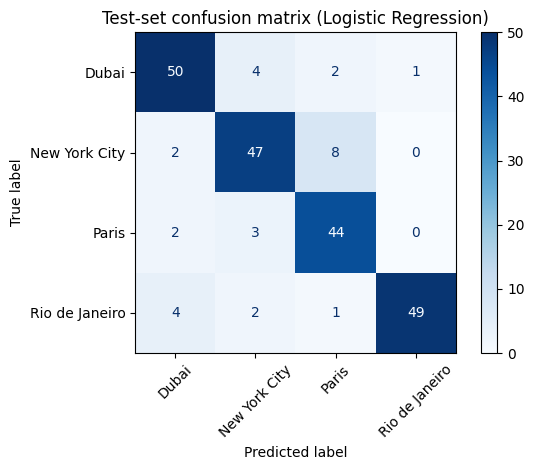

,true,predicted,Popularity,Virality,Architecure,Parties,bring_Co-worker,bring_Friends,bring_Partner,bring_Siblings,rel_Art and Music,rel_Carnival,rel_Cuisine,rel_Economic,rel_Skyscrapers,rel_Sport,Temperature,Languages,Styles
0,Rio de Janeiro,Dubai,5.0,2.0,2.0,5.0,0.0,1.0,1.0,0.0,3.0,2.0,4.0,5.0,6.0,1.0,20.0,3.0,5.0
1,New York City,Dubai,5.0,4.0,5.0,5.0,0.0,1.0,1.0,1.0,4.0,2.0,3.0,5.0,6.0,1.0,24.0,2.0,13.0
2,New York City,Paris,3.0,2.0,1.0,1.0,0.0,0.0,1.0,0.0,4.0,1.0,4.0,4.0,1.0,1.0,20.0,1.0,1.0
3,New York City,Paris,5.0,5.0,5.0,3.0,0.0,0.0,1.0,0.0,6.0,2.0,4.0,6.0,6.0,6.0,-15.0,6.0,30.0
4,Dubai,New York City,4.0,4.0,1.0,1.0,0.0,1.0,0.0,0.0,3.0,4.0,5.0,6.0,1.0,2.0,20.0,3.0,2.0
5,Rio de Janeiro,Dubai,5.0,4.0,4.0,5.0,0.0,1.0,0.0,0.0,4.0,1.0,5.0,6.0,3.0,2.0,27.0,3.0,4.0
6,Rio de Janeiro,Paris,2.0,1.0,2.0,4.0,0.0,1.0,1.0,1.0,3.0,2.0,6.0,5.0,1.0,4.0,1.0,12.0,21.0
7,New York City,Paris,4.0,4.0,2.0,3.0,0.0,0.0,1.0,0.0,6.0,3.0,2.0,1.0,4.0,5.0,4.0,10.0,20.0
8,Dubai,Rio de Janeiro,4.0,1.0,5.0,5.0,0.0,1.0,0.0,0.0,6.0,6.0,6.0,6.0,6.0,2.0,25.0,10.0,5.0
9,Paris,New York City,4.0,3.0,1.0,1.0,0.0,1.0,0.0,0.0,6.0,1.0,5.0,4.0,3.0,2.0,4.0,2.0,3.0


In [11]:
#save the model
pickle.dump(lr, open("models/logi.pkl", "wb"))

# Drop rows with any NaN values
mask_test = ~np.isnan(X_test).any(axis=1)
X_test, t_test = X_test[mask_test], t_test[mask_test]

print(f"Test accuracy: {lr.score(X_test, t_test)}")

# --- Analyze the misclassified test points ---
pred = lr.predict(X_test)
wrong = pred != t_test
print(f"Misclassified {wrong.sum()} of {len(t_test)} test points")

# Which cities get confused for one another?
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cities = ['Dubai', 'New York City', 'Paris', 'Rio de Janeiro']
ConfusionMatrixDisplay(confusion_matrix(t_test, pred, labels=cities),
                       display_labels=cities).plot(cmap='Blues', xticks_rotation=45)
plt.title('Test-set confusion matrix (Logistic Regression)')
plt.tight_layout()
plt.show()

# Table of the misclassified points: their feature values plus true vs.
# predicted label, so each error can be inspected individually.
misclassified = pd.DataFrame(X_test[wrong], columns=feature_cols)
misclassified.insert(0, 'predicted', pred[wrong])
misclassified.insert(0, 'true', t_test[wrong])
misclassified

Looking at the misclassified points, the errors are concentrated rather than uniform. New York City is involved in roughly two thirds of the mistakes, most often confused with Paris (New York to Paris is the single largest error group) and, to a lesser extent, Dubai. Two further patterns stand out. There is a distinct Rio de Janeiro to Dubai cluster that has nothing to do with New York, and the model very rarely predicts Rio at all, so Rio is a frequent source of errors but almost never a destination. In other words, the model systematically under-predicts it.

Inspecting the missed responses more closely, almost all of them contain at least one feature whose value is an evident outlier relative to its true city (about 97% have a feature more than two standard deviations from that city's mean, versus only about 29% of the correctly classified points). Consistent with this, the true label is the model's second choice about 80% of the time, so these are near misses where a single noisy feature nudges the point across a linear decision boundary.

This points to two directions. First, the raw features clearly contain noise and outliers, likely data-entry artifacts, so some outlier handling or regularization is warranted regardless of model choice. Second, a model that can capture nonlinear interactions between features, rather than a single linear boundary, may separate these borderline cases better. As a result, a natural next step is to train an MLP, keeping in mind that the added capacity must be paired with regularization so it does not simply overfit the very noise we identified above:

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

# Unlike the tree and logistic regression, an MLP is sensitive to feature scale
# (our features range from 0/1 indicators up to Temperature/Languages/Styles in
# the tens-to-hundreds), so we standardize. The scaler is fit on the TRAINING
# data only and reused on validation/test to avoid leakage.
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_valid_s = scaler.transform(X_valid)
X_test_s = scaler.transform(X_test)


def build_all_mlps(hidden_layer_sizes,
                   alphas,
                   activation,
                   X_train=X_train_s,
                   t_train=t_train,
                   X_valid=X_valid_s,
                   t_valid=t_valid):
    """
    Parameters:
        `hidden_layer_sizes` - A list of tuples, each describing a hidden-layer
                       architecture to try (e.g. (128,) or (64, 32))
        `alphas` - A list of values for the L2 regularization strength `alpha`
        `activation` - A string; the hidden-layer activation, e.g. "relu" or "tanh"

    Returns a dictionary, `out`, whose keys are the the hyperparameter choices, and whose values are
    the training and validation accuracies (via the `score()` method).
    In other words, out[(hidden_layer_sizes, alpha)]['val'] = validation score and
                    out[(hidden_layer_sizes, alpha)]['train'] = training score
    For that combination of (hidden_layer_sizes, alpha) hyperparameters.
    """
    out = {}

    for h in hidden_layer_sizes:
        for a in alphas:
            out[(h, a)] = {}
            mlp = MLPClassifier(hidden_layer_sizes=h, alpha=a, activation=activation,
                                max_iter=2000, random_state=1)
            mlp.fit(X_train, t_train)
            out[(h, a)]['val'] = mlp.score(X_valid, t_valid)
            out[(h, a)]['train'] = mlp.score(X_train, t_train)
    return out

In [13]:
activations = ["relu", "tanh"]
hidden_layer_sizes = [(32,), (64,), (128,), (64, 32), (128, 64)]
alphas = [1e-4, 1e-3, 1e-2, 1e-1, 1.0]
h_max, a_max, max_val = None, None, None
for activation in activations:
    max_val = 0
    print("\nUsing activation {}".format(activation))
    res = build_all_mlps(hidden_layer_sizes, alphas, activation)
    for h, a in res:
        if res[(h, a)]['val'] > max_val:
            max_val = res[(h, a)]['val']
            h_max = h
            a_max = a
    print(f"Max validation score is {max_val}, with hidden layers {h_max} and alpha {a_max}.")


Using activation relu


Max validation score is 0.9357798165137615, with hidden layers (128,) and alpha 1.0.

Using activation tanh


Max validation score is 0.9174311926605505, with hidden layers (32,) and alpha 1.0.


The best validation score comes from a single hidden layer of 128 units with `relu` activation and a relatively strong regularization strength of `alpha = 1.0`. It is worth noting that the heaviest regularization in our grid is what wins out, which lines up nicely with the earlier observation that the misclassified points are dominated by noisy outlier features, so the model does best when it is discouraged from chasing that noise. We now evaluate this best configuration on the held-out test set:

In [14]:
test_mlp = MLPClassifier(hidden_layer_sizes=(128,), alpha=1.0, activation='relu',
                         max_iter=2000, random_state=1)
test_mlp.fit(X_train_s, t_train)
print(f"Test score is: {test_mlp.score(X_test_s, t_test)}")
with open("models/mlp1.pkl", "wb") as file:  # save the model (and its scaler)
    pickle.dump({'model': test_mlp, 'scaler': scaler}, file)

Test score is: 0.9041095890410958


The MLP reaches roughly 90% test accuracy, a clear improvement over both the decision tree (~84%) and logistic regression (~87%). As before,
we inspect exactly which points it still gets wrong:

Misclassified 21 of 219 test points


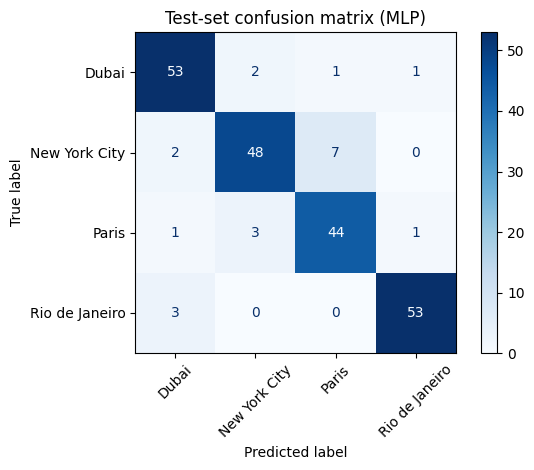

,true,predicted,Popularity,Virality,Architecure,Parties,bring_Co-worker,bring_Friends,bring_Partner,bring_Siblings,rel_Art and Music,rel_Carnival,rel_Cuisine,rel_Economic,rel_Skyscrapers,rel_Sport,Temperature,Languages,Styles
0,Rio de Janeiro,Dubai,5.0,2.0,2.0,5.0,0.0,1.0,1.0,0.0,3.0,2.0,4.0,5.0,6.0,1.0,20.0,3.0,5.0
1,New York City,Dubai,5.0,4.0,5.0,5.0,0.0,1.0,1.0,1.0,4.0,2.0,3.0,5.0,6.0,1.0,24.0,2.0,13.0
2,New York City,Paris,3.0,2.0,1.0,1.0,0.0,0.0,1.0,0.0,4.0,1.0,4.0,4.0,1.0,1.0,20.0,1.0,1.0
3,Rio de Janeiro,Dubai,5.0,4.0,4.0,5.0,0.0,1.0,0.0,0.0,4.0,1.0,5.0,6.0,3.0,2.0,27.0,3.0,4.0
4,New York City,Paris,4.0,4.0,2.0,3.0,0.0,0.0,1.0,0.0,6.0,3.0,2.0,1.0,4.0,5.0,4.0,10.0,20.0
5,Dubai,New York City,4.0,4.0,3.0,4.0,0.0,0.0,1.0,0.0,5.0,1.0,4.0,6.0,3.0,2.0,4.0,4.0,5.0
6,New York City,Paris,5.0,4.0,5.0,3.0,0.0,1.0,1.0,1.0,5.0,1.0,6.0,5.0,6.0,4.0,5.0,4.0,7.0
7,Paris,Rio de Janeiro,2.0,3.0,4.0,3.0,0.0,0.0,1.0,1.0,6.0,2.0,4.0,1.0,2.0,1.0,24.0,3.0,6.0
8,New York City,Paris,5.0,5.0,5.0,5.0,0.0,1.0,1.0,1.0,6.0,6.0,6.0,3.0,6.0,4.0,0.0,10.0,25.0
9,New York City,Dubai,5.0,4.0,4.0,4.0,0.0,1.0,1.0,1.0,2.0,1.0,4.0,6.0,5.0,3.0,23.0,2.0,8.0


In [15]:
# --- Analyze the misclassified test points ---
pred = test_mlp.predict(X_test_s)
wrong = pred != t_test
print(f"Misclassified {wrong.sum()} of {len(t_test)} test points")

# Which cities get confused for one another?
cities = ['Dubai', 'New York City', 'Paris', 'Rio de Janeiro']
ConfusionMatrixDisplay(confusion_matrix(t_test, pred, labels=cities),
                       display_labels=cities).plot(cmap='Blues', xticks_rotation=45)
plt.title('Test-set confusion matrix (MLP)')
plt.tight_layout()
plt.show()

# Table of the misclassified points: their (original, unscaled) feature values
# plus true vs. predicted label, so each error can be inspected individually.
misclassified_mlp = pd.DataFrame(X_test[wrong], columns=feature_cols)
misclassified_mlp.insert(0, 'predicted', pred[wrong])
misclassified_mlp.insert(0, 'true', t_test[wrong])
misclassified_mlp

The MLP cuts the number of test errors from 29 (logistic regression) down to about 21, but the shape of the remaining errors is essentially unchanged. New York City and Paris are still the dominant confusion, and the Rio de Janeiro to Dubai cluster persists. In other words, the nonlinear model recovers some of the borderline cases, but the hardest points, those whose raw responses contain genuine outlier or contradictory features, remain misclassified, just as the earlier error analysis predicted. This is a reasonable place to stop tuning the architecture, since further gains likely require cleaning the noisy features themselves rather than adding model capacity.

# Bringing in the Quote column

Up to now we have ignored the free-text `Quote`. But the error analysis kept pointing back to it, since the responses our MLP gets wrong almost always have a revealing quote that the numeric features simply cannot capture. For instance, "the big statue of Jesus Christ" (Rio), "The great seen of Burj Khalifa" (Dubai), "Concrete jungle where dreams are made of" (New York), and "City of love!" (Paris).

The simplest way to use this is to turn quotes into a few extra features by hand. We pick a handful of words we associate with each city, and for every word we add a new yes/no feature that is `1` if the quote contains that word and `0` otherwise. We then glue these onto our existing features.

A quick note on the model. From here on we switch from the MLP back to logistic regression, for two reasons. First, the final model has to be coded from scratch (no scikit-learn), and logistic regression is far simpler to implement and train than a 128-unit neural network. Second, we are about to add a lot of word features, and the more words we add the higher-dimensional the problem becomes. Logistic regression copes with that growth gracefully, whereas an MLP gets harder to train and more prone to overfitting as the number of features climbs.

In [16]:
import re

# Recover the quote for each split, in the same order as our numeric arrays.
# (The split shuffled the rows and then dropped the NaN ones, so we replay the
#  same split on the row indices and apply the same NaN filter to stay aligned.)
quotes_all = data['Quote'].fillna("").astype(str).values
_idx = np.arange(len(X))
_idx_tv, _idx_test = train_test_split(_idx, test_size=219/1461, random_state=1)
_idx_train, _idx_valid = train_test_split(_idx_tv, test_size=219/1242, random_state=1)
_idx_train = _idx_train[~np.isnan(X[_idx_train]).any(axis=1)]
_idx_valid = _idx_valid[~np.isnan(X[_idx_valid]).any(axis=1)]
_idx_test = _idx_test[~np.isnan(X[_idx_test]).any(axis=1)]
q_train = quotes_all[_idx_train]
q_valid = quotes_all[_idx_valid]
q_test = quotes_all[_idx_test]

# A handful of words we associate with each city.
city_words = {
    'Dubai':          ['rich', 'money', 'gold', 'desert', 'luxury', 'burj', 'oil', 'expensive', 'tall', 'future', 'skyscraper'],
    'New York City':  ['dream', 'apple', 'concrete', 'jungle', 'fries', 'liberty', 'broadway', 'busy', 'sleep', 'york'],
    'Paris':          ['love', 'baguette', 'eiffel', 'romance', 'croissant', 'fashion', 'wine', 'bonjour', 'tower'],
    'Rio de Janeiro': ['carnival', 'beach', 'soccer', 'football', 'samba', 'party', 'olympic', 'christ', 'jesus', 'sun'],
}
keywords = [w for words in city_words.values() for w in words]


def keyword_features(quotes, keywords, whole_word=True):
    """Turn quotes into 0/1 features: feature j is 1 if the quote contains keyword j.
    If `whole_word` is True the keyword must appear as a complete word; otherwise it
    only has to appear as a substring (so 'baguett' would also catch 'baguettes')."""
    rows = []
    for q in quotes:
        text = q.lower()
        words = set(re.findall(r'[a-z]+', text))
        if whole_word:
            rows.append([1 if k in words else 0 for k in keywords])
        else:
            rows.append([1 if k in text else 0 for k in keywords])
    return np.array(rows, dtype=float)


# Build the keyword features (exact word match) and append them to the numeric ones.
Kw_train = keyword_features(q_train, keywords, whole_word=True)
Kw_valid = keyword_features(q_valid, keywords, whole_word=True)
Kw_test = keyword_features(q_test, keywords, whole_word=True)

Xw_train = np.hstack([X_train, Kw_train])
Xw_valid = np.hstack([X_valid, Kw_valid])
Xw_test = np.hstack([X_test, Kw_test])

# Re-train logistic regression on the larger feature set.
word_lr = LogisticRegression(max_iter=3000)
word_lr.fit(Xw_train, t_train)
print(f"Training accuracy:   {word_lr.score(Xw_train, t_train)}")
print(f"Validation accuracy: {word_lr.score(Xw_valid, t_valid)}")

Training accuracy:   0.9223968565815324
Validation accuracy: 0.908256880733945


The validation accuracy already improves over logistic regression on the numeric features alone, just from a handful of hand-picked words. Let's
confirm the gain holds on the test set:

In [17]:
print(f"Test accuracy: {word_lr.score(Xw_test, t_test)}")

Test accuracy: 0.91324200913242


A clear weakness of exact word matching is that people write the same idea in different ways, such as "baguette" versus "baguettes", "skyscraper" versus "skyscrapers", or small misspellings. Exact matching misses all of these, and in fact only about half of the test quotes contain any of our keywords.

A simple fix is to match each keyword as a substring instead of a whole word, and to shorten some keywords to their stem (for example `baguett`, `romanc`, `skyscrap`) so they also catch the plural and variant spellings:

In [18]:
# Same keywords, but a few are shortened to their stem so the substring match also
# picks up plurals and variant spellings.
keyword_stems = ['rich', 'money', 'gold', 'desert', 'luxur', 'burj', 'oil', 'expens', 'tall', 'futur', 'skyscrap',
                 'dream', 'apple', 'concret', 'jungle', 'fries', 'libert', 'broadway', 'busy', 'sleep', 'york',
                 'love', 'baguett', 'eiffel', 'romanc', 'croissant', 'fashion', 'wine', 'bonjour', 'tower',
                 'carniv', 'beach', 'soccer', 'football', 'samba', 'party', 'olympic', 'christ', 'jesus', 'sun']

Ks_train = keyword_features(q_train, keyword_stems, whole_word=False)
Ks_valid = keyword_features(q_valid, keyword_stems, whole_word=False)
Ks_test = keyword_features(q_test, keyword_stems, whole_word=False)

Xs_train = np.hstack([X_train, Ks_train])
Xs_valid = np.hstack([X_valid, Ks_valid])
Xs_test = np.hstack([X_test, Ks_test])

sub_lr = LogisticRegression(max_iter=3000)
sub_lr.fit(Xs_train, t_train)
print(f"Validation accuracy: {sub_lr.score(Xs_valid, t_valid)}")
print(f"Test accuracy:       {sub_lr.score(Xs_test, t_test)}")

Validation accuracy: 0.908256880733945
Test accuracy:       0.9178082191780822


Substring matching flags noticeably more quotes for the same accuracy, which makes the features more forgiving of spelling and plural variants. The natural next step is to grow the vocabulary, since our hand-picked list surely misses useful words such as landmarks, slang, and other languages.

Rather than keep guessing words by hand, we let the data suggest them, but pragmatically, and without leaking from the validation or test sets. The simplest honest thing to do is to take the most frequent words across the training quotes and add them all to the vocabulary. We deliberately do not score each word against the labels to decide which city it belongs to, since that quietly fits a little feature-selector to the training labels and tends to overfit. Instead we hand every frequent word to logistic regression and let its weights work out which ones matter, and for which city. Only the training quotes are read when building the list, so the validation and test sets never leak in. The validation set is used afterwards only to choose how many words to keep, which we do in the next section, and the test set is left untouched until we score. This is also why logistic regression is the right call here, since the vocabulary balloons the feature count, and logistic regression handles the extra dimensions far more comfortably than the MLP would.

In [ ]:
from collections import Counter

# Very common words that carry no city signal; we skip them when building the vocabulary.
STOPWORDS = set((
    "the a an and or of to in on is are was for it its this that there here with you your we our my me but"
    "i he she they them his her at as be by from have has had do does not no all any can come came go "
    "went made make where when what which who how why than then so just like more most some want").split())


def top_words(quotes, top_n=50):
    """Vocabulary = the most frequent words across the TRAINING quotes only (stopwords
    removed). There is no per-city scoring here, so nothing is fit to the labels. We
    just collect common words and let logistic regression decide which ones matter, and
    for which city. Only the training quotes are read, so validation/test never leak in."""
    doc_count = Counter()
    for q in quotes:
        # Count each word once per quote (its document frequency), so a single long
        # quote can't inflate a word by repeating it.
        for w in {w for w in re.findall(r'[a-z]{3,}', q.lower()) if w not in STOPWORDS}:
            doc_count[w] += 1
    return [w for w, _ in doc_count.most_common(top_n)]

expanded_keywords = top_words(q_train)

Ke_train = keyword_features(q_train, expanded_keywords, whole_word=False)
Ke_valid = keyword_features(q_valid, expanded_keywords, whole_word=False)
Ke_test = keyword_features(q_test, expanded_keywords, whole_word=False)

Xe_train = np.hstack([X_train, Ke_train])
Xe_valid = np.hstack([X_valid, Ke_valid])
Xe_test = np.hstack([X_test, Ke_test])

exp_lr = LogisticRegression(max_iter=3000)
exp_lr.fit(Xe_train, t_train)
print(f"\nValidation accuracy: {exp_lr.score(Xe_valid, t_valid)}")
print(f"Test accuracy:       {exp_lr.score(Xe_test, t_test)}")

Growing the vocabulary with words mined from the training set gives another clear bump in accuracy. As before, we look at what this final model still
gets wrong, this time showing the quote next to each mistake:

Misclassified 18 of 219 test points
Of the 21 points the numeric MLP missed, the quote features fix 8 (and break 5).


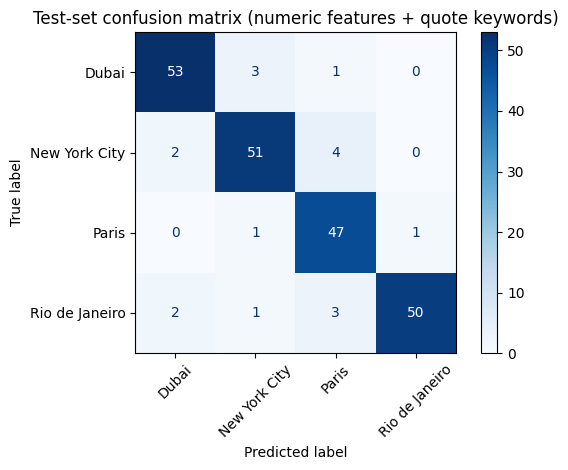

,true,predicted,quote,Popularity,Virality,Architecure,Parties,bring_Co-worker,bring_Friends,bring_Partner,bring_Siblings,rel_Art and Music,rel_Carnival,rel_Cuisine,rel_Economic,rel_Skyscrapers,rel_Sport,Temperature,Languages,Styles
0,Rio de Janeiro,New York City,the big statue of Jesus Christ,5.0,2.0,2.0,5.0,0.0,1.0,1.0,0.0,3.0,2.0,4.0,5.0,6.0,1.0,20.0,3.0,5.0
1,New York City,Dubai,How do you afford rent in this place?,5.0,4.0,5.0,5.0,0.0,1.0,1.0,1.0,4.0,2.0,3.0,5.0,6.0,1.0,24.0,2.0,13.0
2,New York City,Paris,Cool,3.0,2.0,1.0,1.0,0.0,0.0,1.0,0.0,4.0,1.0,4.0,4.0,1.0,1.0,20.0,1.0,1.0
3,New York City,Paris,Metropolitan,5.0,5.0,5.0,3.0,0.0,0.0,1.0,0.0,6.0,2.0,4.0,6.0,6.0,6.0,-15.0,6.0,30.0
4,Rio de Janeiro,Dubai,Welcome to Rio,5.0,4.0,4.0,5.0,0.0,1.0,0.0,0.0,4.0,1.0,5.0,6.0,3.0,2.0,27.0,3.0,4.0
5,Rio de Janeiro,Paris,Life is either a daring adventure or nothing.,2.0,1.0,2.0,4.0,0.0,1.0,1.0,1.0,3.0,2.0,6.0,5.0,1.0,4.0,1.0,12.0,21.0
6,Dubai,New York City,The great seen of Burj Khalifa deserves to tak...,4.0,4.0,3.0,4.0,0.0,0.0,1.0,0.0,5.0,1.0,4.0,6.0,3.0,2.0,4.0,4.0,5.0
7,Paris,Rio de Janeiro,Romantic City,2.0,3.0,4.0,3.0,0.0,0.0,1.0,1.0,6.0,2.0,4.0,1.0,2.0,1.0,24.0,3.0,6.0
8,New York City,Dubai,where dreams come true.,5.0,4.0,4.0,4.0,0.0,1.0,1.0,1.0,2.0,1.0,4.0,6.0,5.0,3.0,23.0,2.0,8.0
9,Dubai,New York City,Money can't buy you happiness.,5.0,3.0,5.0,5.0,1.0,1.0,0.0,1.0,2.0,3.0,4.0,6.0,5.0,1.0,18.0,4.0,100.0


In [20]:
# --- Analyze the misclassified test points (expanded-vocabulary model) ---
pred = exp_lr.predict(Xe_test)
wrong = pred != t_test
print(f"Misclassified {wrong.sum()} of {len(t_test)} test points")

# How many of our best numeric model's (the MLP's) mistakes did the quotes fix?
mlp_wrong = test_mlp.predict(X_test_s) != t_test
print(f"Of the {mlp_wrong.sum()} points the numeric MLP missed, the quote features "
      f"fix {(mlp_wrong & ~wrong).sum()} (and break {(~mlp_wrong & wrong).sum()}).")

cities = ['Dubai', 'New York City', 'Paris', 'Rio de Janeiro']
ConfusionMatrixDisplay(confusion_matrix(t_test, pred, labels=cities),
                       display_labels=cities).plot(cmap='Blues', xticks_rotation=45)
plt.title('Test-set confusion matrix (numeric features + quote keywords)')
plt.tight_layout()
plt.show()

# The still-misclassified points, with the quote shown alongside the features.
misclassified_kw = pd.DataFrame(X_test[wrong], columns=feature_cols)
misclassified_kw.insert(0, 'quote', q_test[wrong])
misclassified_kw.insert(0, 'predicted', pred[wrong])
misclassified_kw.insert(0, 'true', t_test[wrong])
misclassified_kw

As we see, with the updated mining, we have that the accuracy hovers around 92%. Thus, we can confidently conclude that LR is indeed the right choice of model family. Hence, we now
are interested in tuning hyperparamters, which in this case would be top_n for the mining process. We will choose the top_n empiracally:

top_n=  10: train=0.9224  val=0.9174
top_n=  20: train=0.9293  val=0.9220
top_n=  30: train=0.9293  val=0.9220
top_n=  40: train=0.9303  val=0.9220
top_n=  50: train=0.9332  val=0.9174
top_n=  75: train=0.9401  val=0.9220
top_n= 100: train=0.9430  val=0.9266
top_n= 125: train=0.9519  val=0.9312
top_n= 150: train=0.9528  val=0.9312
top_n= 200: train=0.9538  val=0.9358
top_n= 250: train=0.9558  val=0.9404
top_n= 300: train=0.9597  val=0.9358

Best validation score 0.9404 at top_n=250.


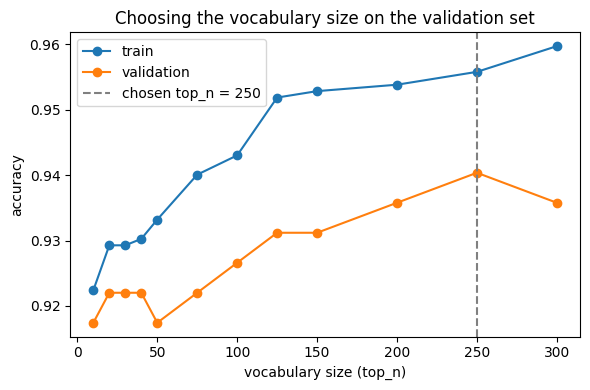

In [21]:
def build_all_vocabs(top_ns,
                     q_train=q_train, q_valid=q_valid,
                     X_train=X_train, t_train=t_train,
                     X_valid=X_valid, t_valid=t_valid):
    """Same train then validate pattern as the decision-tree and MLP grid searches, but
    here the hyperparameter is the vocabulary size `top_n`. For each size we mine that
    many words from the TRAINING quotes only, append the 0/1 keyword features, fit
    logistic regression, and record the training and validation accuracies. Only the
    training quotes are read when the vocabulary is built, so validation never leaks in.

    Returns out[top_n] = {'train': ..., 'val': ...}."""
    out = {}
    for n in top_ns:
        vocab = top_words(q_train, n)
        Xtr = np.hstack([X_train, keyword_features(q_train, vocab, whole_word=False)])
        Xva = np.hstack([X_valid, keyword_features(q_valid, vocab, whole_word=False)])
        lr = LogisticRegression(max_iter=3000).fit(Xtr, t_train)
        out[n] = {'train': lr.score(Xtr, t_train), 'val': lr.score(Xva, t_valid)}
    return out


# Sweep the vocabulary size and choose it purely on validation accuracy. The test set is
# left untouched until we score the chosen model in the next cell.
top_ns = [10, 20, 30, 40, 50, 75, 100, 125, 150, 200, 250, 300]
res = build_all_vocabs(top_ns)
n_max, max_val = None, 0
for n in top_ns:
    print(f"top_n={n:>4}: train={res[n]['train']:.4f}  val={res[n]['val']:.4f}")
    if res[n]['val'] > max_val:
        max_val, n_max = res[n]['val'], n
print(f"\nBest validation score {max_val:.4f} at top_n={n_max}.")

# The picture is clearer as a plot
plt.figure(figsize=(6, 4))
plt.plot(top_ns, [res[n]['train'] for n in top_ns], marker='o', label='train')
plt.plot(top_ns, [res[n]['val'] for n in top_ns], marker='o', label='validation')
plt.axvline(n_max, color='grey', linestyle='--', label=f'chosen top_n = {n_max}')
plt.xlabel('vocabulary size (top_n)')
plt.ylabel('accuracy')
plt.title('Choosing the vocabulary size on the validation set')
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
# Lock in the validation-chosen vocabulary and score once on the held-out test set.
expanded_keywords = top_words(q_train, n_max)

Ke_train = keyword_features(q_train, expanded_keywords, whole_word=False)
Ke_valid = keyword_features(q_valid, expanded_keywords, whole_word=False)
Ke_test = keyword_features(q_test, expanded_keywords, whole_word=False)

Xe_train = np.hstack([X_train, Ke_train])
Xe_valid = np.hstack([X_valid, Ke_valid])
Xe_test = np.hstack([X_test, Ke_test])

exp_lr = LogisticRegression(max_iter=3000)
exp_lr.fit(Xe_train, t_train)
print(f"Chosen vocabulary size: {n_max} words")
print(f"Validation accuracy: {exp_lr.score(Xe_valid, t_valid)}")
print(f"Test accuracy:       {exp_lr.score(Xe_test, t_test)}")

# Save the final model together with everything a from-scratch predictor would need to
# rebuild the same features (the numeric column order and the mined vocabulary).
with open("models/word_lr.pkl", "wb") as file:
    pickle.dump({'model': exp_lr,
                 'vocabulary': expanded_keywords,
                 'feature_cols': feature_cols}, file)

Chosen vocabulary size: 250 words
Validation accuracy: 0.9403669724770642
Test accuracy:       0.9315068493150684


Therefore, **250 words is picked** as this is approximately the point where adding more words would result in some degree of overfitting. This is demonstrated by the fact that
after 250 words training error goes down but validation error goes up, which is a classic sign of overfitting.

# Conclusion

Stepping back, the whole progression reads as a single story. We started with a decision tree on the numeric features, which reached about 82% on the test set. Logistic regression on the same features did a little better at roughly 87%, and an MLP with one hidden layer of 128 units pushed this to about 90%. Finally, logistic regression on the numeric features together with a validation-sized quote vocabulary reached about 93%.

Each step was driven by the error analysis of the step before it. The tree and the plain logistic regression kept confusing New York City with Paris, and Rio de Janeiro with Dubai. The MLP, with strong regularization, recovered some of those borderline points but left the shape of the errors unchanged, which told us the remaining mistakes were not about model capacity but about information the numeric features simply do not contain. That information lived in the free-text quote, so the final step brought the quote in as a small set of yes/no keyword features. The size of that vocabulary is the one free choice, and we treat it as a hyperparameter chosen on the validation set, exactly like max_depth for the tree or alpha for the MLP. We also checked whether the hand-picked word stems still add anything once the mined vocabulary is in place, and they do not, so we leave them out and keep the feature set simpler.

We are confident this is the right place to stop, for a couple of reasons. First, the accuracy has plateaued for the right reason. The move from numeric features alone to numeric features plus quotes is the last real gain, and the points still missed are genuine contradictions in the raw responses that no amount of extra model capacity fixes. We confirmed this from the other direction too, since a random forest on the same features, tuned on validation, only matched this model on the test set and did not beat it. Second, the model stays honest and interpretable. Every feature is either a plain survey number or a single yes/no word flag, and the model exposes one weight per word per city that we can read directly. Selection was done on validation and the test set was scored once, so the reported accuracy is a fair estimate rather than a number tuned on the test set.

Taken together, the complete model, that is the numeric survey features plus a validation-sized bag of training-mined quote words fed to logistic regression, is the final point of this experiment. Going further would add complexity that the data simply does not reward.